<a href="https://colab.research.google.com/github/anirbansen2709/Build-and-Train-an-LLM-with-JAX/blob/main/a_building_the_architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#importing libraries
import jax
import jax.numpy as jnp
import flax.nnx as nnx

import matplotlib.pyplot as plt

**Create the embedding layers**

In [14]:
class TokenAndPositionEmbedding(nnx.Module):
  def __init__(self, maxlen, vocab_size, embed_dim, *, rngs):
    self.token_emb = nnx.Embed(vocab_size, embed_dim, rngs = rngs)
    self.pos_emb = nnx.Embed(maxlen, embed_dim, rngs = rngs)

  def __call__(self, x):
    seq_len = x.shape[1]
    positions = jnp.arage(seq_len)[None, :]
    return self.token_emb(x) + self.pos_emb(positions)

In [15]:
def causal_attention_mask(seq_len):
  return jnp.tril(jnp.ones((seq_len, seq_len)))

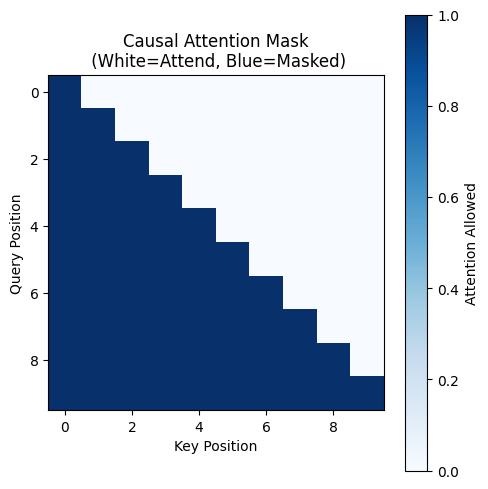

In [16]:
mask = causal_attention_mask(10)
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap = "Blues", interpolation="nearest")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.title("Causal Attention Mask\n (White=Attend, Blue=Masked)")
plt.colorbar(label="Attention Allowed")
plt.tight_layout()
plt.show()

**Build the Transformer layer**

In [17]:
class TransformerBlock(nnx.Module):
  def __init__(self, embed_dim, num_heads, ff_dim, *, rngs):
    self.attention = nnx.MultiHeadAttention(
        num_heads = num_heads,
        in_features=embed_dim,
        qkv_features=embed_dim,
        out_features=embed_dim,
        decode=False,
        rngs=rngs
    )
  def __call__(self, x, mask=None):
    attn_out = self.attention(x, mask=mask)
    x = x + attn_out # residual connection
    return x

**Define the model configuration**

In [18]:
class MiniGPT(nnx.Module):
  def __init__(self, maxlen, vocab_size, embed_dim, num_heads,
               feed_forward_dim, num_transformer_blocks, *, rngs):
    self.maxlen = maxlen
    self.embedding = TokenAndPositionEmbedding(maxlen, vocab_size,
                                               embed_dim, rngs = rngs)
    self.transformer_blocks = [
        TransformerBlock(embed_dim, num_heads, feed_forward_dim, rngs = rngs)
        for _ in range(num_transformer_blocks)
    ]
    self.output_layer = nnx.Linear(embed_dim, vocab_size, use_bias=False,
                                   rngs = rngs)

  def causal_attention_mask(self, seq_len):
    return jnp.tril(jnp.ones(seq_len, seq_len))

  def __call__(self, token_ids):
    seq_len = token_ids.shape[1]
    mask = self.causal_attention_mask(seq_len)
    x = self.embedding(token_ids)
    for block in self.transformer_blocks:
      x = block(x, mask = mask)
    logits = self.output_layer(x)
    return logits

**Final Model**

In [19]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
tokenizer.n_vocab

50257

In [21]:
model = MiniGPT(
    maxlen = 128,
    vocab_size = tokenizer.n_vocab,
    embed_dim = 192,
    num_heads = 6,
    feed_forward_dim = 512,
    num_transformer_blocks = 6,
    rngs = nnx.Rngs(0)
)

In [22]:
model

MiniGPT( # Param: 20,212,608 (80.9 MB)
  maxlen=128,
  embedding=TokenAndPositionEmbedding( # Param: 9,673,920 (38.7 MB)
    token_emb=Embed( # Param: 9,649,344 (38.6 MB)
      embedding=Param( # 9,649,344 (38.6 MB)
        value=Array(shape=(50257, 192), dtype=dtype('float32'))
      ),
      num_embeddings=50257,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      embedding_init=<function variance_scaling.<locals>.init at 0x7b66251e2c00>,
      promote_dtype=<function promote_dtype at 0x7b6624e634c0>
    ),
    pos_emb=Embed( # Param: 24,576 (98.3 KB)
      embedding=Param( # 24,576 (98.3 KB)
        value=Array(shape=(128, 192), dtype=dtype('float32'))
      ),
      num_embeddings=128,
      features=192,
      dtype=dtype('float32'),
      param_dtype=float32,
      embedding_init=<function variance_scaling.<locals>.init at 0x7b66251e2c00>,
      promote_dtype=<function promote_dtype at 0x7b6624e634c0>
    )
  ),
  transformer_blocks=[TransformerBloc